<a href="https://colab.research.google.com/github/nishka-pandya/E-Commerce-Fraud-Detecting-Prediction-Model/blob/main/KWK_Machine_Learning_x_Finance_Challenge_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Detecting E-Commerce Fraud
---

## ⚠️ Agreement Not to Use AI Tools in This Text Cell

By completing this text cell, you confirm that **you did not use any AI tools or large language models (LLMs) to generate text, code, or analysis for its content**.  

*Purpose:* This ensures that your insights, reasoning, and work in this section are fully your own.  

**I agree that I did not use any AI tools or large language models (LLMs) to generate text, code, or analysis for its content**

-----------------

## Research Question / Problem Statement
What methods can be used to detect fraud in E-commerce platforms?
-----------------

## List of Datasets
**Instructions:** Include dataset name, source/link, and a brief description. Explain why you chose it.
1. https://www.kaggle.com/datasets/umuttuygurr/e-commerce-fraud-detection-dataset This is a dataset from Kaggle that contains information that can help determine whether or not there is a fraud. I chose it because it is a dataset designed to be a e-commerce website that has data on thousands of usuers. The dataset has a lot of columns that would help determine fraudulent behavior so I can explore and experiment with many columns.


-----------------

## Summary of Dataset Use

**Instructions:** For each model you train, fill out the following section (template to copy/pase is below this list):
1.  Model type (e.g. linear regression)
2.  Dataset(s) used
3.  The metric(s) you used to evaluate the model (e.g. accuracy, f1 score, R-squared, RMSE, feature importance)
4.  The key insight(s) you discovered through training and evaluating your model.
5.  Did you use AI or LLMs to support your work on this model? If so, briefly, what did you use them for? (e.g. code generation, asking conceptual questions, etc.)

#### Model 1
*   **Decision Tree**:

*   **Kaggle E-Commerce Fraud Detection Dataset**:

*   **Accuracy, Recall, Precision, F1 Score**:

*   **Key Insight(s): : Highest feature importance was account_age_days which did not have a high correlation to is_fraud, while the lowest feature importance was cvv_result which was surprising because it had the highest correlation with is_fraud**

*   **Asking conceptual questions such as how to determine whether a model is effective based on accuracy and F1 score with general examples so I can better understand metrics.**

#### Model 2
*   **Random Forests**:

*   **Kaggle E-Commerce Fraud Detection Dataset**:

*   **Accuracy, F1 Score, Recall, Precision, and Confusion Matrix**

*   **Key Insight(s)**: In the confusion matrix, the model detected a lot of true negatives and true positives compared to false positives and false negatives

*   **Asking conceptual questions such as how to determine whether a model is effective based on accuracy and F1 score with general examples so I can better understand metrics.**



-----------------

### Overall AI/LLM Usage
**Instructions:** If you used AI or LLM tools during any part of the learning or project process, please describe your overall uses here. This may include using AI tools as a tutor, to understand code, to fix bugs, or to generate code.

**Used it to understand conceptual questions such as how to determine whether a model is effective based on accuracy and F1 score with general examples**

**Used to understand what types of verification can be used instead of only avs_match and cvs_result, such as digital fingerprints.**

**Used to understand how I could potentially improve f1 score and recall**

**For improvement in model section of presentation (next steps), ChatGPT recommended to use gradient modeling**

-----------------

## Results

Overall, both machine learning models had high accuracy for both testing and training sets that were not very far apart from each other. However, it is important to note that the f1 score and recall for both the training and testing sets for both models had a huge percentage of around 30%. However, at least the random forest model is feasible to use because the confusion matrix detected most true positives and true negatives compared to any false. It would be great to try more advanced models in the future to increase f1 score and recall! According the basic data analysis, shipping distance and amount have high positive correlation and can be further explored in individual user accounts to detect more patterns.


-----------------

## Conclusion and Recommendations
1) Random Forests: A good model to use for simplicity while providing accuracy as seen in metrics and correlation matrix

2) Large Distance: Between Billing and Shipping Address: If the shipping distance is large, implement further verifications that notify the user IMMEDIATELY through email, phone, messages, etc.


3) Identity Verification: Besides CVV_result and AVS_match, other verification can strengthen chances of identifying fraud quickly such as digital fingerprints


4) Compare Amount of Transaction to Average Amount: If the transaction amount is larger, implement further verifications that notify the user IMMEDIATELY through email, phone, messages, etc. Its important to further analyze transactions that are extremely higher than the user's average transactions because amount is positively correlated to is_fraud.


-----------------

## References
**Instructions:** Include links to any additional resources, articles, etc. that you used to help interpret results, draw conclusions, and/or make recommendations

1. https://www.statista.com/topics/9240/e-commerce-fraud/?srsltid=AfmBOopn7TjWcbQVKnsfjkJno7SKlM7exHDnBdMbYaLr9QAOTjg_e32S#topicOverview

2. Used Kode with Klossy resources such as example code-along to code visualizations and models


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from scipy import stats

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/transactions.csv')
df.head()

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299695 entries, 0 to 299694
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           299695 non-null  int64  
 1   user_id                  299695 non-null  int64  
 2   account_age_days         299695 non-null  int64  
 3   total_transactions_user  299695 non-null  int64  
 4   avg_amount_user          299695 non-null  float64
 5   amount                   299695 non-null  float64
 6   country                  299695 non-null  object 
 7   bin_country              299695 non-null  object 
 8   channel                  299695 non-null  object 
 9   merchant_category        299695 non-null  object 
 10  promo_used               299695 non-null  int64  
 11  avs_match                299695 non-null  int64  
 12  cvv_result               299695 non-null  int64  
 13  three_ds_flag            299695 non-null  int64  
 14  tran

In [ ]:
#feature engineering

#can create new columns focusing on individual times

#convert from object to date time

df['transaction_time'] = pd.to_datetime(df['transaction_time'])

#month

df['month'] = df['transaction_time'].dt.month

#day
df['day'] = df['transaction_time'].dt.day

#day of week
df['day_of_week'] = (df['transaction_time'].dt.dayofweek) + 1

print(df['day_of_week'].min())
print(df['day_of_week'].max())
print("\n")

#hour
df['hour'] = df['transaction_time'].dt.hour
print(df['hour'].min())
print(df['hour'].max())
print("\n")


#year

df['year'] = df['transaction_time'].dt.year


#create boolean for machine learning


#weekend?

df['is_weekend'] = df['day_of_week'].isin([6,7]).astype(int)


#night?

df['is_night'] = df['hour'].isin([0,5]).astype(int)
print(df['is_night'].max())
print(df['is_night'].min())


#season?









1
7


0
23


1
0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299695 entries, 0 to 299694
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype              
---  ------                   --------------   -----              
 0   transaction_id           299695 non-null  int64              
 1   user_id                  299695 non-null  int64              
 2   account_age_days         299695 non-null  int64              
 3   total_transactions_user  299695 non-null  int64              
 4   avg_amount_user          299695 non-null  float64            
 5   amount                   299695 non-null  float64            
 6   country                  299695 non-null  object             
 7   bin_country              299695 non-null  object             
 8   channel                  299695 non-null  object             
 9   merchant_category        299695 non-null  object             
 10  promo_used               299695 non-null  int64              
 11  avs_match    

In [ ]:
df.drop(df['isWeekend'], inplace = True, axis = 1)

NameError: name 'df' is not defined

In [ ]:
df.head()

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,...,shipping_distance_km,is_fraud,day,day_of_week,hour,month,year,isWeekend,is_weekend,is_night
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,...,370.95,0,6,6,4,1,2024,1,1,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,...,149.62,0,9,2,20,1,2024,0,0,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,...,164.08,0,12,5,6,1,2024,0,0,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,...,397.40,0,15,1,17,1,2024,0,0,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,...,935.28,0,17,3,1,1,2024,0,0,0


Analysis: It seems as though the data is already clean because all values are non-null.

In [ ]:
#calculating measures of central tendency using continuous and discrete variables
cols = ["total_transactions_user","avg_amount_user","amount", "account_age_days", "shipping_distance_km"]

for col in cols:
 #mean
 mean = df[col].mean()
 #median
 median = df[col].median()
 #mode
 mode_result = stats.mode(df[col], keepdims = True)
 mode_age = mode_result.mode[0]
 mode_count = mode_result.count[0]
 print(f"\n---{col.upper()}---")
 print(f"Mean: {mean}")
 print(f"Median: {median}")
 print(f"Mode {mode_age} appears {mode_count} times")



---TOTAL_TRANSACTIONS_USER---
Mean: 50.67332120989673
Median: 51.0
Mode 60 appears 16680 times

---AVG_AMOUNT_USER---
Mean: 148.1429728891039
Median: 90.13
Mode 33.17 appears 233 times

---AMOUNT---
Mean: 177.16527856654264
Median: 89.99
Mode 5.0 appears 1527 times

---ACCOUNT_AGE_DAYS---
Mean: 973.3978711690219
Median: 975.0
Mode 695 appears 677 times

---SHIPPING_DISTANCE_KM---
Mean: 357.0490276781394
Median: 273.02
Mode 43.38 appears 19 times


What does the mean, median, and mode tell us?

1) The average total transactions per user is 50, and the median is 51. This suggests that there are very few outliers because the mean is close to the median.

2) For the avg_amount_user, the mean is 148, while the median is 90.13. This suggests that the data has large outliers.

3) For amount, the mean is 177.17 and the median is 89.99, once again, suggesting outliers.

4) For account_age_days, the mean is 973.4 and the median is 975.0. This suggests that there are very few outliers.

5) For shipping distance, the mean is 357.05 while the median is 273.02, which suggests that the mean has large outliers.

In [ ]:
#calculating spread and variation
#continous and discrete quantitative variables

cols = ["total_transactions_user","avg_amount_user","amount", "account_age_days", "shipping_distance_km"]

for col in cols:
  print(f"\n---{col.upper()}--")
  max = df[col].max()
  min = df[col].min()
  range = max - min

  iqr = df[col].quantile(0.75) - df[col].quantile(0.25)

  std_dev = df[col].std()
  variance = df[col].var()

  print(f"Max: {max}")
  print(f"Min: {min}")
  print(f"Range: {range:,.1f}")
  print(f"IQR: {iqr:,.1f}")
  print(f"Standard Deviation: {std_dev:,.1f}")
  print(f"Variance: {variance:,.1f}")



---TOTAL_TRANSACTIONS_USER--
Max: 60
Min: 40
Range: 20.0
IQR: 10.0
Standard Deviation: 6.0
Variance: 35.7

---AVG_AMOUNT_USER--
Max: 4565.29
Min: 3.52
Range: 4,561.8
IQR: 127.3
Standard Deviation: 200.4
Variance: 40,146.0

---AMOUNT--
Max: 16994.74
Min: 1.0
Range: 16,993.7
IQR: 149.0
Standard Deviation: 306.9
Variance: 94,203.9

---ACCOUNT_AGE_DAYS--
Max: 1890
Min: 1
Range: 1,889.0
IQR: 909.0
Standard Deviation: 525.2
Variance: 275,878.5

---SHIPPING_DISTANCE_KM--
Max: 3748.56
Min: 0.0
Range: 3,748.6
IQR: 272.6
Standard Deviation: 427.7
Variance: 182,903.4


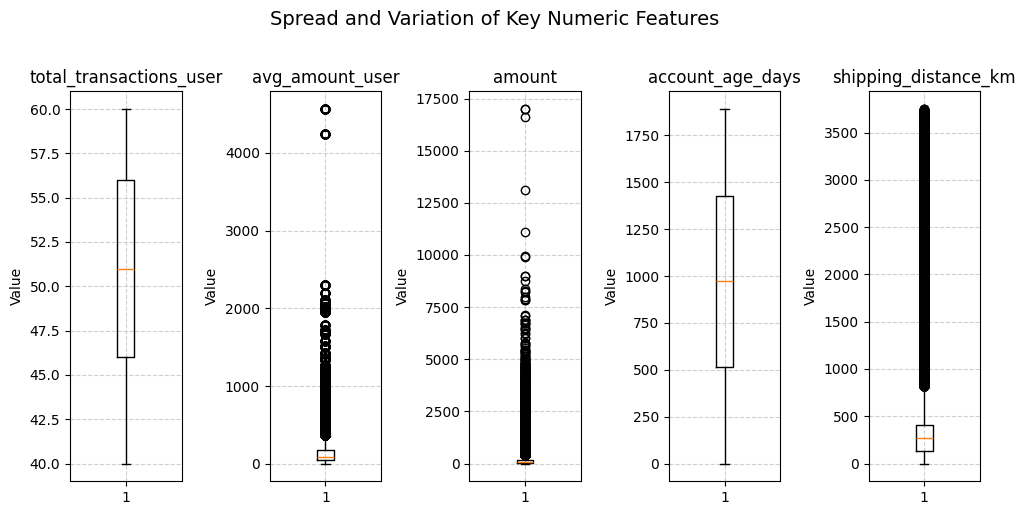

In [ ]:
import matplotlib.pyplot as plt

cols = ["total_transactions_user","avg_amount_user","amount", "account_age_days", "shipping_distance_km"]

fig, axes = plt.subplots(nrows = 1, ncols = len(cols), figsize = (10, 5))

for i, col in enumerate(cols):
  axes[i].boxplot(df[col].dropna(), vert = True)
  axes[i].set_title(col)
  axes[i].set_ylabel("Value")
  axes[i].grid(True, linestyle= "--", alpha = 0.6)

plt.suptitle("Spread and Variation of Key Numeric Features", fontsize = 14, y=1.02)
plt.tight_layout()
plt.show()

total_transactions_user: seems to have the least variance.

avg_amount_user: The IQR is very low, and there are a lot of outliers.

amount: Most variance

account_age_days: very little outliers

shipping_distance_km: Also has a lot of outliers.

The ones with the outliers have a large distance between median and mean.

In [ ]:
#correlation matrix

#-1, perfect negative correlation (goes up/down by same proportional amount)
#1, perfect positive correlation
#0, no correlation

cols = ["total_transactions_user","avg_amount_user","amount",
        "account_age_days", "shipping_distance_km",
        "is_fraud", "promo_used", "avs_match", "cvv_result", "three_ds_flag"]

df[cols].corr()


,total_transactions_user,avg_amount_user,amount,account_age_days,shipping_distance_km,is_fraud,promo_used,avs_match,cvv_result,three_ds_flag
total_transactions_user,1.000000,-0.004743,-0.005819,-0.034347,-0.005559,-0.017093,-0.000636,0.007444,0.004464,0.002968
avg_amount_user,-0.004743,1.000000,0.731955,-0.009951,-0.000942,-0.001236,0.001628,0.001514,0.003170,0.000016
amount,-0.005819,0.731955,1.000000,-0.032084,0.053686,0.202499,0.013794,-0.044093,-0.042007,-0.034103
account_age_days,-0.034347,-0.009951,-0.032084,1.000000,-0.031924,-0.120340,-0.018416,0.026525,0.027605,0.018643
shipping_distance_km,-0.005559,-0.000942,0.053686,-0.031924,1.000000,0.270004,0.015265,-0.059766,-0.062243,-0.045130
is_fraud,-0.017093,-0.001236,0.202499,-0.120340,0.270004,1.000000,0.067351,-0.223299,-0.218982,-0.162160
promo_used,-0.000636,0.001628,0.013794,-0.018416,0.015265,0.067351,1.000000,-0.013678,-0.012061,-0.008786
avs_match,0.007444,0.001514,-0.044093,0.026525,-0.059766,-0.223299,-0.013678,1.000000,0.531155,0.255365
cvv_result,0.004464,0.003170,-0.042007,0.027605,-0.062243,-0.218982,-0.012061,0.531155,1.000000,0.469381
three_ds_flag,0.002968,0.000016,-0.034103,0.018643,-0.045130,-0.162160,-0.008786,0.255365,0.469381,1.000000


Find which variables have strongest correlation to fraud:

Total Transactions of User: 0.017, negative

Average Amount of User: 0.0012, negative

Amount: 0.2, positive

Account age: 0.12, negative

Shipping distance: 0.27, positive

Promo Used: 0.067, positive

Avs match: 0.223, negative

Cvv result: 0.219, negative

Three ds flag: 0.16, negative

It seems as though shipping distance, AVS match, and CVV result have the strongest correlation. AVS match is the address verification result and CVV result is the CVV code match result. As the likelihood of fraud increases, CVV code match result and AVS match decreases. Both CVV result and AVS match are binary represented by 0 and 1.



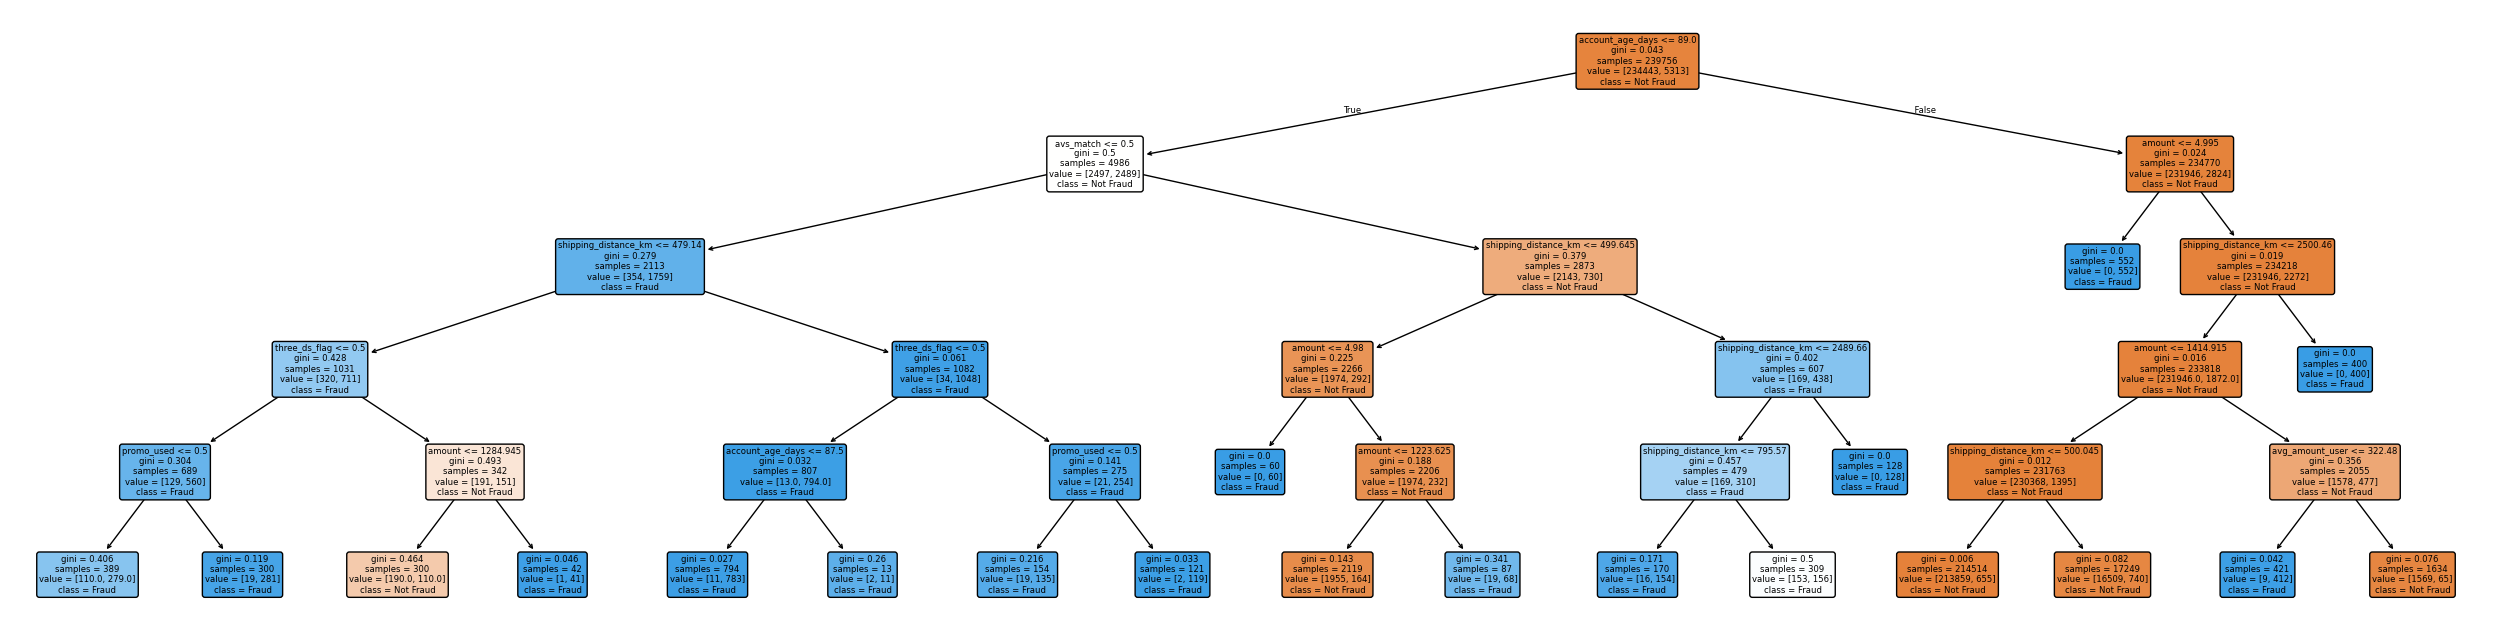


Feature Importance:
                    Feature  Importance
3         account_age_days    0.350529
2                   amount    0.225654
4     shipping_distance_km    0.198943
6                avs_match    0.123182
1          avg_amount_user    0.089239
8            three_ds_flag    0.009752
5               promo_used    0.002701
0  total_transactions_user    0.000000
7               cvv_result    0.000000



ACCURACY FOR THE TRAINING SET
Accuracy: 0.9912619496488096

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00    234443
           1       0.91      0.67      0.77      5313

    accuracy                           0.99    239756
   macro avg       0.95      0.84      0.88    239756
weighted avg       0.99      0.99      0.99    239756

ACCURACY FOR THE TEST SET
Accuracy: 0.9911409933432322

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      

In [ ]:
#decision tree

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt


X = df[["total_transactions_user","avg_amount_user","amount",
        "account_age_days", "shipping_distance_km", "promo_used", "avs_match", "cvv_result", "three_ds_flag"]]
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

model = DecisionTreeClassifier(
    criterion = "gini",
    max_depth = 5,
    random_state = 42
)
model.fit(X_train, y_train)

plt.figure(figsize=(32,8))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Not Fraud", "Fraud"],
    filled = True,
    rounded = True
)
plt.show()

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending = False)

print("\nFeature Importance:\n", feature_importance)
print("\n\n")

print("ACCURACY FOR THE TRAINING SET")
y_pred_train = model.predict(X_train)
print("Accuracy:", accuracy_score(y_train, y_pred_train))
print("\nClassification Report:\n", classification_report(y_train, y_pred_train))


print("ACCURACY FOR THE TEST SET")
y_pred_test = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))




ACCURACY FOR TRAINING SET
Accuracy: 0.9900398738717696

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99    234443
           1       0.95      0.58      0.72      5313

    accuracy                           0.99    239756
   macro avg       0.97      0.79      0.86    239756
weighted avg       0.99      0.99      0.99    239756


ACCURACY FOR TESTING SET
Accuracy: 0.9901566592702581

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99     58640
           1       0.96      0.57      0.72      1299

    accuracy                           0.99     59939
   macro avg       0.97      0.79      0.86     59939
weighted avg       0.99      0.99      0.99     59939



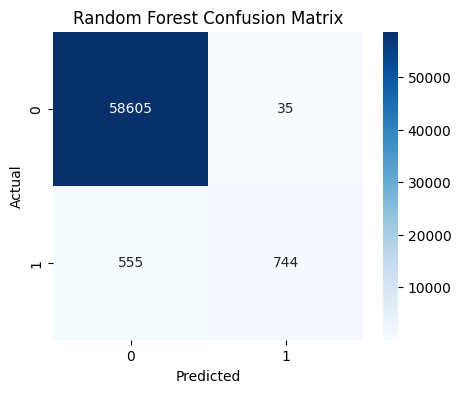


Feature Importance
                    Feature  Importance
3         account_age_days    0.334781
2                   amount    0.286557
4     shipping_distance_km    0.231136
6                avs_match    0.067856
7               cvv_result    0.036517
8            three_ds_flag    0.019365
1          avg_amount_user    0.015216
5               promo_used    0.008286
0  total_transactions_user    0.000285


In [ ]:
#random forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns

X = df[["total_transactions_user","avg_amount_user","amount",
        "account_age_days", "shipping_distance_km", "promo_used", "avs_match", "cvv_result", "three_ds_flag"]]
y = df["is_fraud"]

#set up train + testing
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size = 0.2, random_state = 42
)

#set up model
forest = RandomForestClassifier(
    n_estimators = 100,    #number of trees in the forest
    max_depth = 5,        #max depth of each tree to avoid overfitting
    min_samples_split = 5, #min samples to split internal node
    min_samples_leaf = 2, #min samples allowed in leaf
    random_state = 42

)

forest.fit(X_train, y_train)

#set up the training prediction
print("\nACCURACY FOR TRAINING SET")
y_pred_train = forest.predict(X_train)
print("Accuracy:" , accuracy_score(y_train, y_pred_train))
print("\nClassification Report:\n", classification_report(y_train, y_pred_train))

#set up the testing prediction
print("\nACCURACY FOR TESTING SET")
y_pred_test = forest.predict(X_test)
print("Accuracy:" , accuracy_score(y_test, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))

#confusion matrix
plt.figure(figsize= (5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot = True, fmt = "d", cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

#feature importance
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest.feature_importances_}).sort_values(by = "Importance", ascending = False)

print("\nFeature Importance\n", importance_df)

In [ ]:
#testing for overfitting or underfitting



In [ ]:
#check to see actual value of 0 and 1 in the column

fraud = 0
not_fraud = 0

for i in df["is_fraud"]:
 if i == 1:
  fraud = fraud + 1
 else:
  not_fraud = not_fraud + 1

print(f"Fraud: {fraud}")
print(f"Not Fraud: {not_fraud}")

Fraud: 6612
Not Fraud: 293083
